# Séance 3 / Analyse spatiale avancée avec GeoPandas 🌐 📒

*   SCR, modélisations, géométrie
*   Jointure spatiales et agrégations spatiales
*   Calcul de distance, de surface et zones tampons
*   Opérateur de recouvrement (intersect, difference, union,...)
*   Création d'index spatial
*   Analyse du plus proche voisin
*   Carroyage classique
*   Carroyage basé sur le Uber H3
*   Récupérer des données de Overture Maps

Documentation Geopandas : https://geopandas.org/en/stable/docs/reference.html

    
    
    
   


## Configuration de l'environnement de travail 🧰





In [ ]:
#Initialisation de l'environnement avec geopandas
!apt update
!apt install gdal-bin python-gdal python3-gdal
# Install rtree - Geopandas requirment (index spatial)
!apt install python3-rtree
# Install Geopandas (manipulation données spatiales)
!pip install geopandas
# Instal contextily (fonds de carte)
!pip install contextily
# Install mapclassify (cartographie thématique)
!pip install mapclassify
#Depuis sa version 0.8, Geopandas peut fonctionner de manière expérimental avec Pygeos ce qui accèlère certaines opérations
!pip install pygeos
# Install scalebar
!pip install matplotlib_scalebar

In [ ]:
#Importation des librairies nécessaires
from shapely.geometry import LineString, Point, Polygon
import pandas as pd #Gestion de données
import matplotlib.pyplot as plt #Visualisation de données
import seaborn # Visualisation de données avancée
import geopandas as gpd #Gestion données spatiales
import contextily as ctx #Fonds de carte
import numpy as np #Manipulation de tableaux
import shapely #Manipulation de géométrie
import folium #Cartographie interactive
import mapclassify #Cartographie thématique
from matplotlib_scalebar.scalebar import ScaleBar #Echelle cartographique

## Importation et préparation des données de la séance ⬇️

In [ ]:
#Téléchargement des datas depuis le site opendata de Paris
!wget -O velibs.geojson https://opendata.paris.fr/explore/dataset/velib-disponibilite-en-temps-reel/download/?format=geojson&timezone=Europe/Berlin&lang=fr
!wget -O IRIS.geojson https://data.iledefrance.fr/explore/dataset/iris/download/?format=geojson&refine.dep=75&timezone=Europe/Berlin&lang=fr

#### Couche des IRIS

<Axes: >

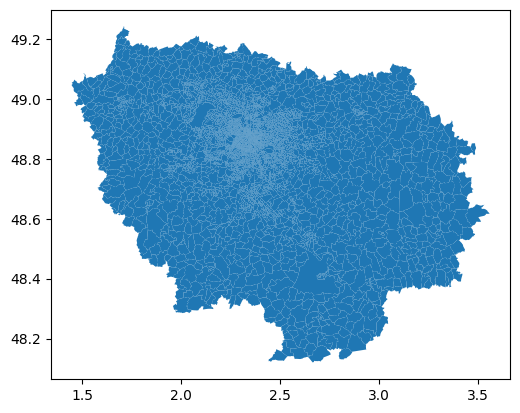

In [ ]:
#Importer et reprojeter la couche des IRIS
IRIS= gpd.read_file("IRIS.geojson", encoding='utf-8') #Charger la couche
IRIS.plot() # Afficher la couche

<Axes: >

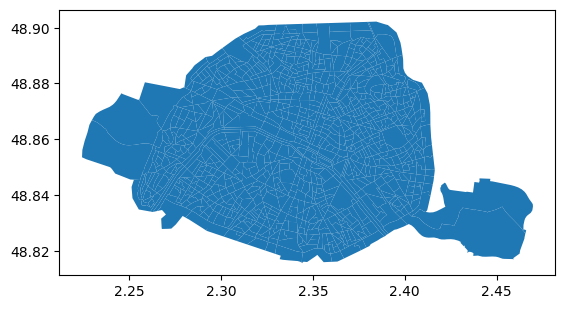

In [ ]:
#Garder que les IRIS de Paris
IRIS = IRIS[(IRIS["dep"]== '75')]
IRIS.plot()

<Axes: >

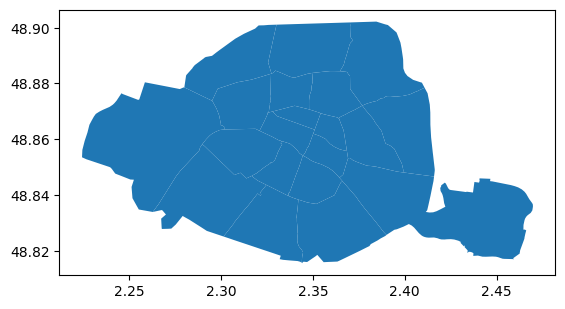

In [ ]:
# Créer une couche des arrondissements
ARDT = IRIS.dissolve(by='nom_com')
ARDT.plot()

#### Couche des Velibs

,name,stationcode,ebike,mechanical,coordonnees_geo,duedate,numbikesavailable,numdocksavailable,capacity,is_renting,is_installed,nom_arrondissement_communes,is_returning,code_insee_commune,geometry
0,Cassini - Denfert-Rochereau,14111,3,2,"[48.837525839067, 2.3360354080796]",2026-03-05 16:13:49+00:00,5,19,25,OUI,OUI,Paris,OUI,75056,POINT (651265.173 6859924.253)
1,Benjamin Godard - Victor Hugo,16107,2,4,"[48.865983, 2.275725]",2026-03-05 16:13:56+00:00,6,29,35,OUI,OUI,Paris,OUI,75056,POINT (646867.548 6863127.314)
4,Charonne - Robert et Sonia Delaunay,11104,0,0,"[48.855907555969, 2.3925706744194]",2026-03-05 16:15:24+00:00,0,20,20,OUI,OUI,Paris,OUI,75056,POINT (655430.484 6861934.722)


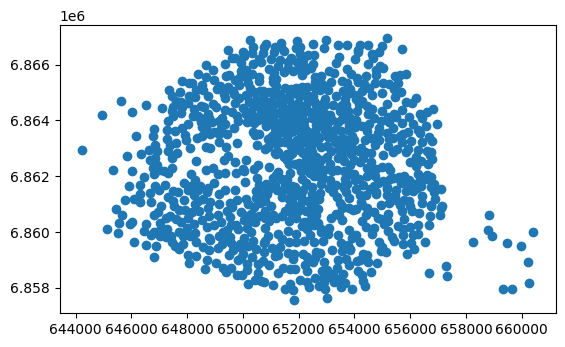

In [ ]:
#Importer et reprojeter la couche des velibs et faire une couche des velibs de Paris

Velibs= gpd.read_file("velibs.geojson", encoding='utf-8')
Velibs = Velibs.to_crs(2154)
VelibParis = Velibs[(Velibs["nom_arrondissement_communes"] == 'Paris')]
VelibParis.plot()
VelibParis.head(3)

In [ ]:
# Ne garder que les champs intéressants et les renommer

VelibParis = VelibParis[["name", "stationcode", "ebike", "mechanical", "numbikesavailable", "numdocksavailable", "capacity", "geometry"]]
VelibParis = VelibParis.rename(columns={'name': 'Nom', 'stationcode':'Code', 'ebike': 'Veloselectriques', 'ebike': 'Veloselectriques', 'mechanical': 'Velosmecaniques', 'numbikesavailable': 'Velosdispo', 'numdocksavailable': 'Soclesdispo', 'capacity': 'Capacite'})
VelibParis.head()

,Nom,Code,Veloselectriques,Velosmecaniques,Velosdispo,Soclesdispo,Capacite,geometry
0,Cassini - Denfert-Rochereau,14111,3,2,5,19,25,POINT (2.33604 48.83753)
1,Benjamin Godard - Victor Hugo,16107,2,4,6,29,35,POINT (2.27572 48.86598)
4,Charonne - Robert et Sonia Delaunay,11104,0,0,0,20,20,POINT (2.39257 48.85591)
6,Messine - Place Du Pérou,8026,1,9,10,2,12,POINT (2.31551 48.87545)
7,Toudouze - Clauzel,9020,3,0,3,16,21,POINT (2.33736 48.8793)


#### Couche des pistes cyclables

In [ ]:
#Télécharger une couche avec des filtres dans l'appel de l'API

import requests

url = "https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/amenagements-cyclables/exports/geojson?\lang=fr&\
refine=amenagement%3A%22piste%20cyclable%22&\
refine=amenagement%3A%22couloir%20bus%20ouvert%20aux%20v%C3%A9los%22&\
refine=amenagement%3A%22bande%20cyclable%22&\
facet=facet(name%3D%22amenagement%22%2C%20disjunctive%3Dtrue)&\timezone=Europe%2FBerlin"

response = requests.get(url)

if response.status_code == 200:
    with open("pistescyclables.geojson", "wb") as file:
        file.write(response.content)
    print("Téléchargement réussi !")
else:
    print(f"Erreur lors du téléchargement")

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_522/1524034823.py:5: SyntaxWarning: invalid escape sequence '\l'
  url = "https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/amenagements-cyclables/exports/geojson?\lang=fr&\


Téléchargement réussi !


,osm_id,nom,amenagement,cote_amenagement,sens,surface,arrondissement,bois,coronapiste,amenagement_temporaire,infrastructure_bidirection,voie_a_sens_unique,position_amenagement,vitesse_maximale_autorisee,date_export,source,st_length_shape,geo_point_2d,geometry
0,85147124,Rue Manin,piste cyclable,droit,None,Asphalte,19,non,non,non,non,oui,indéfini,non définie,2026-01-01 01:00:00+00:00,OSMIUM,20.607211,"{'lon': 2.378363051172131, 'lat': 48.878754280...","LINESTRING (2.37836 48.87885, 2.37836 48.87877..."
1,91301110,Rue Gros,couloir bus ouvert aux vélos,droit,None,Asphalte,16,non,non,non,non,oui,niveau chaussée,30 km/h,2026-01-01 01:00:00+00:00,OSMIUM,106.519916,"{'lon': 2.277520714092092, 'lat': 48.851378817...","LINESTRING (2.27823 48.85147, 2.27795 48.85141..."
2,112184611,La Coulée Verte,piste cyclable,droit,None,Asphalte,14,non,non,non,oui,non,niveau trottoir,non définie,2026-01-01 01:00:00+00:00,OSMIUM,86.797322,"{'lon': 2.305169113744935, 'lat': 48.828316732...","LINESTRING (2.30555 48.82861, 2.30549 48.82857..."


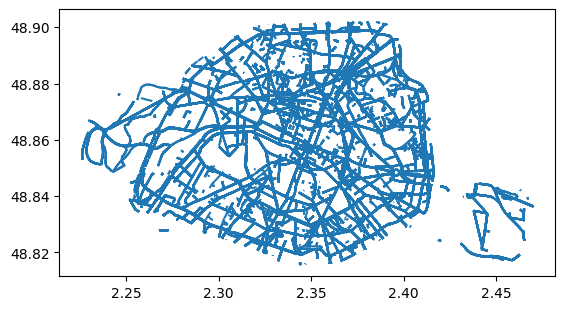

In [ ]:
#Importer la couche des pistes cyclables

pistescyclables= gpd.read_file("pistescyclables.geojson", encoding='utf-8')
pistescyclables.plot()
pistescyclables.head(3)

## Opérateur métriques (surface, longueur, coordonnées...) 📏

In [ ]:
#Calculer la surface des IRIS (en km2)

IRIS = IRIS.to_crs(2154)
IRIS["surface"] = IRIS['geometry'].area/1000000
IRIS.head(5)

,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry,surface
1,A,75112,751124811,Quinze-Vingts 11,75,"[48.844104305775815, 2.3753123018512237]",IRIS____0000000751124811,4811,Paris 12e Arrondissement,"POLYGON ((653849.2 6860793.5, 653962.2 6860809...",0.115311
2,D,75115,751156023,Jardin Citroën-Cévennes,75,"[48.840354178960965, 2.2752169001780462]",IRIS____0000000751156023,6023,Paris 15e Arrondissement,"POLYGON ((646761.8 6860630.1, 646782.5 6860618...",0.142982
34,A,75108,751083006,Faubourg du Roule 6,75,"[48.874120601261225, 2.308949350470029]",IRIS____0000000751083006,3006,Paris 8e Arrondissement,"POLYGON ((649501.3 6863891.5, 649444.3 6863864...",0.040529
35,D,75107,751072812,Champ de Mars,75,"[48.85609158677385, 2.2979056002416494]",IRIS____0000000751072812,2812,Paris 7e Arrondissement,"POLYGON ((648026.7 6862221.3, 648266.6 6862471...",0.268362
80,H,75110,751103902,Porte Saint-Martin 2,75,"[48.87001277527335, 2.36487060942211]",IRIS____0000000751103902,3902,Paris 10e Arrondissement,"POLYGON ((653570.4 6863368, 653449.3 6863312, ...",0.059112


In [ ]:
#Calculer la longueur (en metre) des tronçons des pistes cyclables

pistescyclables = pistescyclables.to_crs(2154)
pistescyclables["longueur"] = pistescyclables['geometry'].length
pistescyclables['longueur'] = round(pistescyclables['longueur'],0)
pistescyclables.head(3)

,osm_id,nom,amenagement,cote_amenagement,sens,surface,arrondissement,bois,coronapiste,amenagement_temporaire,infrastructure_bidirection,voie_a_sens_unique,position_amenagement,vitesse_maximale_autorisee,date_export,source,st_length_shape,geo_point_2d,geometry,longueur
0,85147124,Rue Manin,piste cyclable,droit,None,Asphalte,19,non,non,non,non,oui,indéfini,non définie,2026-01-01 01:00:00+00:00,OSMIUM,20.607211,"{'lon': 2.378363051172131, 'lat': 48.878754280...","LINESTRING (654408.244 6864493.509, 654407.733...",21.0
1,91301110,Rue Gros,couloir bus ouvert aux vélos,droit,None,Asphalte,16,non,non,non,non,oui,niveau chaussée,30 km/h,2026-01-01 01:00:00+00:00,OSMIUM,106.519916,"{'lon': 2.277520714092092, 'lat': 48.851378817...","LINESTRING (647036.826 6861511.575, 647016.109...",107.0
2,112184611,La Coulée Verte,piste cyclable,droit,None,Asphalte,14,non,non,non,oui,non,niveau trottoir,non définie,2026-01-01 01:00:00+00:00,OSMIUM,86.797322,"{'lon': 2.305169113744935, 'lat': 48.828316732...","LINESTRING (649019.12 6858952.416, 649014.201 ...",87.0


## Transformations géométriques 🔲

,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry,surface
1,A,75112,751124811,Quinze-Vingts 11,75,"[48.844104305775815, 2.3753123018512237]",IRIS____0000000751124811,4811,Paris 12e Arrondissement,POINT (654153.815 6860632.189),0.115311
2,D,75115,751156023,Jardin Citroën-Cévennes,75,"[48.840354178960965, 2.2752169001780462]",IRIS____0000000751156023,6023,Paris 15e Arrondissement,POINT (646804.119 6860277.986),0.142982
34,A,75108,751083006,Faubourg du Roule 6,75,"[48.874120601261225, 2.308949350470029]",IRIS____0000000751083006,3006,Paris 8e Arrondissement,POINT (649312.726 6864010.308),0.040529
35,D,75107,751072812,Champ de Mars,75,"[48.85609158677385, 2.2979056002416494]",IRIS____0000000751072812,2812,Paris 7e Arrondissement,POINT (648484.896 6862012.783),0.268362
80,H,75110,751103902,Porte Saint-Martin 2,75,"[48.87001277527335, 2.36487060942211]",IRIS____0000000751103902,3902,Paris 10e Arrondissement,POINT (653410.681 6863519.101),0.059112


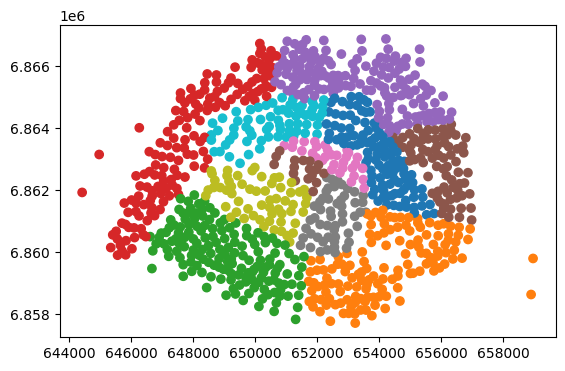

In [ ]:
# Créer une couche de centroides des IRIS

IRIScentro = IRIS.copy()
IRIScentro.geometry = IRIScentro['geometry'].centroid
IRIScentro.plot(column = "nom_com")
IRIScentro.head()

In [ ]:
# Créer une paire de coordonées géographique en WGS84 pour les centroides des IRIS (qui est en 2154)

IRIScentro["Longitude"] = IRIScentro['geometry'].to_crs(4326).x
IRIScentro["Latitude"] = IRIScentro['geometry'].to_crs(4326).y
IRIScentro.head()

,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry,surface,Longitude,Latitude
1,A,75112,751124811,Quinze-Vingts 11,75,"[48.844104305775815, 2.3753123018512237]",IRIS____0000000751124811,4811,Paris 12e Arrondissement,POINT (654153.815 6860632.189),0.115311,2.375312,48.844104
2,D,75115,751156023,Jardin Citroën-Cévennes,75,"[48.840354178960965, 2.2752169001780462]",IRIS____0000000751156023,6023,Paris 15e Arrondissement,POINT (646804.119 6860277.986),0.142982,2.275217,48.840354
34,A,75108,751083006,Faubourg du Roule 6,75,"[48.874120601261225, 2.308949350470029]",IRIS____0000000751083006,3006,Paris 8e Arrondissement,POINT (649312.726 6864010.308),0.040529,2.308949,48.874121
35,D,75107,751072812,Champ de Mars,75,"[48.85609158677385, 2.2979056002416494]",IRIS____0000000751072812,2812,Paris 7e Arrondissement,POINT (648484.896 6862012.783),0.268362,2.297906,48.856092
80,H,75110,751103902,Porte Saint-Martin 2,75,"[48.87001277527335, 2.36487060942211]",IRIS____0000000751103902,3902,Paris 10e Arrondissement,POINT (653410.681 6863519.101),0.059112,2.364871,48.870013


In [ ]:
# Créer les colonnes lat et long des centroides des IRIS en 4326


<Axes: >

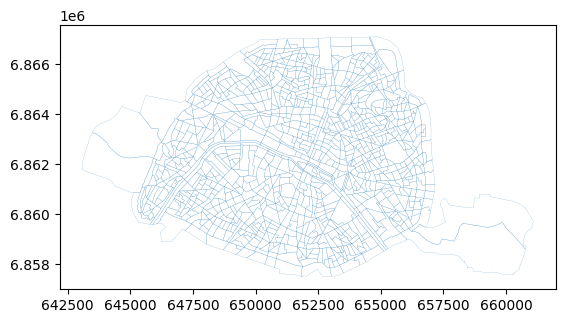

In [ ]:
# Créer une couche de contours des IRIS

IRISContours = IRIS.boundary
IRISContours.plot(linewidth=0.1)

## Jointure spatiale et agrégation statistique 🌐

### Préparation des données

In [ ]:
# Jointure spatiale Velibs <> IRIS

Velibok = gpd.sjoin(VelibParis, IRIS[["code_iris", "geometry"]])
Velibok.head()

,Nom,Code,Veloselectriques,Velosmecaniques,Velosdispo,Soclesdispo,Capacite,geometry,index_right,code_iris
0,Cassini - Denfert-Rochereau,14111,3,2,5,19,25,POINT (651265.173 6859924.253),5015,751145302
1,Benjamin Godard - Victor Hugo,16107,2,4,6,29,35,POINT (646867.548 6863127.314),1802,751166304
4,Charonne - Robert et Sonia Delaunay,11104,0,0,0,20,20,POINT (655430.484 6861934.722),4590,751114411
6,Messine - Place Du Pérou,8026,1,9,10,2,12,POINT (649795.058 6864153.718),714,751083202
7,Toudouze - Clauzel,9020,3,0,3,16,21,POINT (651401.378 6864567.904),1946,751093301


## Agrégation à l'échelle des IRIS

#### Calcul du Nombre de stations par IRIS

In [ ]:
# Compter le nombre de stations de vélibs par IRIS dans un dataframe

NbvelibIRIS  = Velibok[["code_iris", "Code"]].groupby("code_iris").size()
NbvelibIRIS =pd.DataFrame(NbvelibIRIS)
NbvelibIRIS = NbvelibIRIS.rename(columns={0: 'Nbstations'})
NbvelibIRIS.head(5)

,Nbstations
code_iris,
751010101,1
751010102,1
751010103,1
751010201,3
751010202,4


In [ ]:
# Jointure attributaire

IRISStations = IRIS.merge(NbvelibIRIS, left_on='code_iris', right_on='code_iris')
IRISStations.head(3)

,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry,surface,Nbstations
0,A,75112,751124811,Quinze-Vingts 11,75,"[48.844104305775815, 2.3753123018512237]",IRIS____0000000751124811,4811,Paris 12e Arrondissement,"POLYGON ((653849.2 6860793.5, 653962.2 6860809...",0.115311,2
1,D,75115,751156023,Jardin Citroën-Cévennes,75,"[48.840354178960965, 2.2752169001780462]",IRIS____0000000751156023,6023,Paris 15e Arrondissement,"POLYGON ((646761.8 6860630.1, 646782.5 6860618...",0.142982,2
2,A,75108,751083006,Faubourg du Roule 6,75,"[48.874120601261225, 2.308949350470029]",IRIS____0000000751083006,3006,Paris 8e Arrondissement,"POLYGON ((649501.3 6863891.5, 649444.3 6863864...",0.040529,1


Text(0.5, 0, 'Nombre de stations')

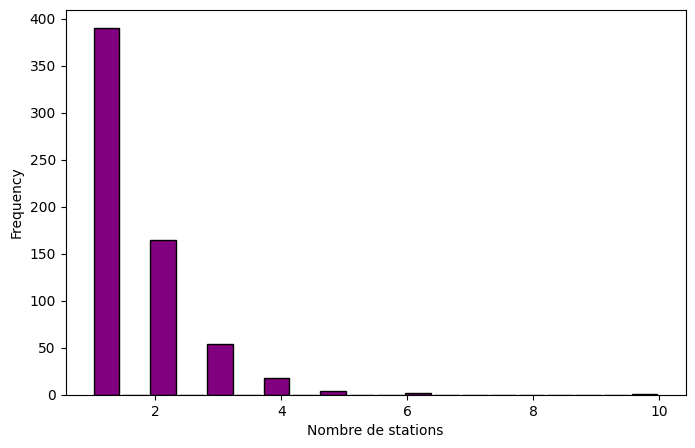

In [ ]:
# Histogramme de distribution des stations par IRIS

ax = IRISStations.plot.hist(y='Nbstations', figsize=(8, 5), bins=20, rwidth=0.9, edgecolor='black', color='purple',legend=False)
ax.set_xlabel('Nombre de stations')

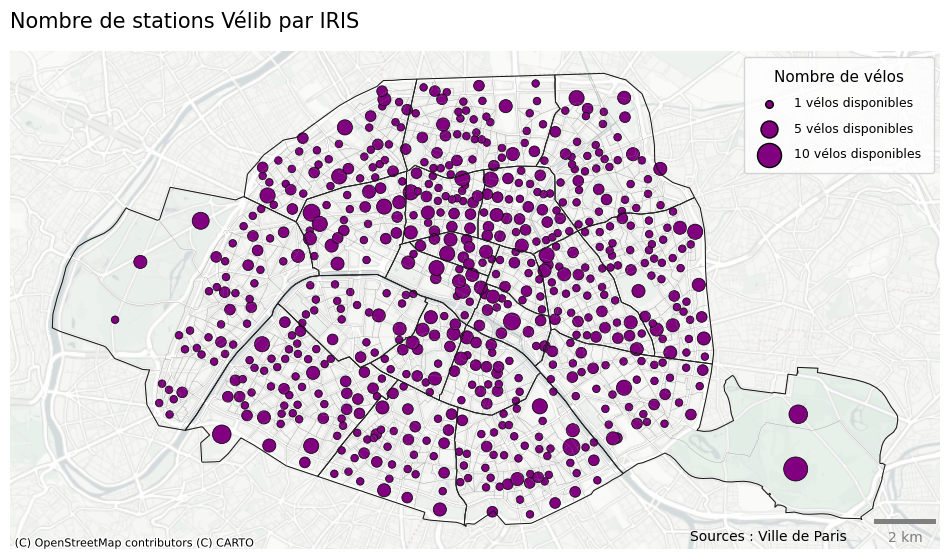

In [ ]:
# Cartographie du nombre de stations vélibs par IRIS

IRISStations.geometry = IRISStations['geometry'].centroid

Carte1, ax = plt.subplots(figsize=(12,12))

ARDT.boundary.to_crs('EPSG:3857').plot(ax=ax, linewidth=0.7, color='black')
IRIS.boundary.to_crs('EPSG:3857').plot(ax=ax, linewidth=0.1, color='grey')

scale = 30

IRISStations.to_crs('EPSG:3857').plot(
    ax=ax,
    markersize=IRISStations["Nbstations"] * scale,
    edgecolor='black',
    linewidth=0.5,
    alpha=1,
    color='purple'
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)

# Valeurs représentées dans la légende
legend_values = [1, 5, 10]

legend_handles = [
    plt.scatter([], [], s=v * scale, color='purple', edgecolor="black")
    for v in legend_values
]

ax.legend(
    legend_handles,
    [f"{v} vélos disponibles" for v in legend_values],
    title="Nombre de vélos",
    loc="upper right",
    fontsize=9,
    title_fontsize=11,
    frameon=True,
    borderpad=1,        # agrandit la boîte
    labelspacing=1,   # espace entre lignes
    handletextpad=1   # espace symbole / texte
)

ax.axis("off")

plt.title('Nombre de stations Vélib par IRIS', loc='left', fontsize=15)

ax.text(
    0.90, 0.01,
    'Sources : Ville de Paris',
    verticalalignment='bottom',
    horizontalalignment='right',
    transform=ax.transAxes,
    fontsize=10
)

ax.add_artist(
    ScaleBar(1, length_fraction=0.1, location="lower right",
             box_alpha=0, color="grey")
)

plt.show()


### Calcul du nombre de Vélos disponibles par IRIS

In [ ]:
# Calculer le nombre de vélos disponibles par IRIS

NbvelibdispoIRIS  = Velibok[["code_iris", "Velosdispo"]].groupby("code_iris").sum()
NbvelibdispoIRIS =pd.DataFrame(NbvelibdispoIRIS)
NbvelibdispoIRIS.head(5)

,Velosdispo
code_iris,
751010101,20
751010102,10
751010103,21
751010201,88
751010202,68


In [ ]:
# Jointure attributaire


,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry,surface,Velosdispo
0,A,75112,751124811,Quinze-Vingts 11,75,"[48.844104305775815, 2.3753123018512237]",IRIS____0000000751124811,4811,Paris 12e Arrondissement,"POLYGON ((653849.2 6860793.5, 653962.2 6860809...",0.115311,98
1,D,75115,751156023,Jardin Citroën-Cévennes,75,"[48.840354178960965, 2.2752169001780462]",IRIS____0000000751156023,6023,Paris 15e Arrondissement,"POLYGON ((646761.8 6860630.1, 646782.5 6860618...",0.142982,108
2,A,75108,751083006,Faubourg du Roule 6,75,"[48.874120601261225, 2.308949350470029]",IRIS____0000000751083006,3006,Paris 8e Arrondissement,"POLYGON ((649501.3 6863891.5, 649444.3 6863864...",0.040529,30


Text(0.5, 0, 'Nombre de socles')

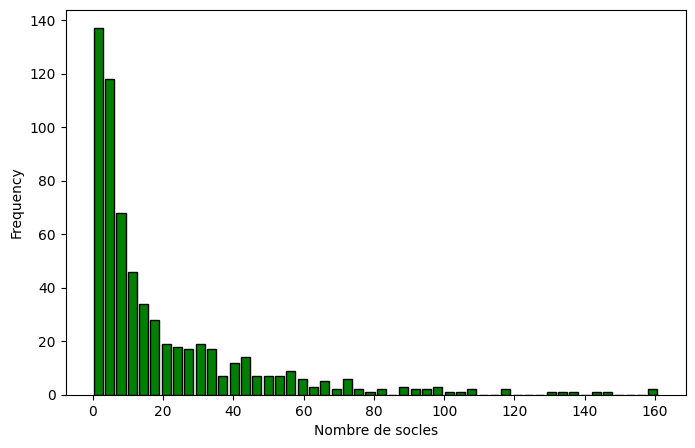

In [ ]:
# Histogramme de distribution des vélibs disponibles par IRIS


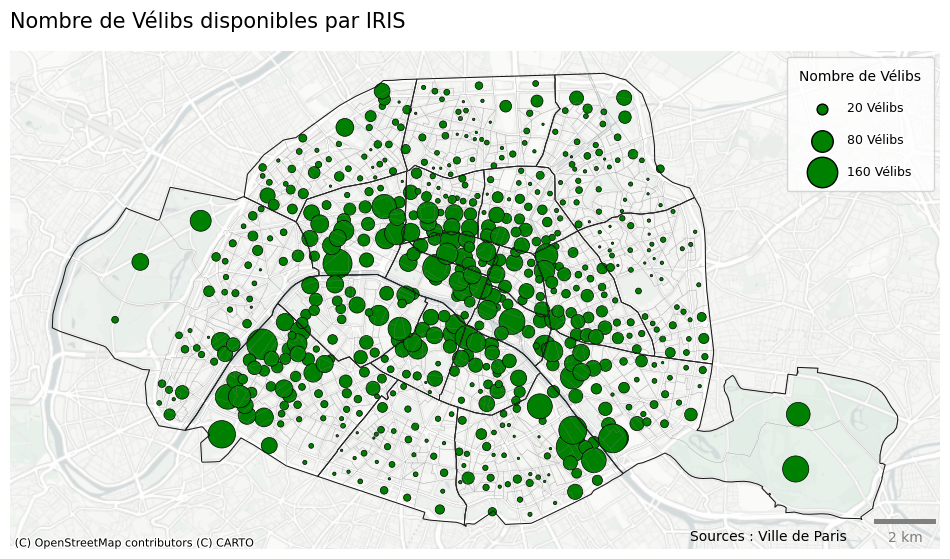

In [ ]:
# Cartographie du nombre de vélos disponible par IRIS




## Exercice autour des pistes cyclables 🚲

* Couper les tronçons des pistes cyclables par les IRIS
* Calculer la somme des longueurs de pistes cyclable par IRIS
* Cartographier cet indicateur selon trois modalités

### Méthodes  : Intersection

In [ ]:
Intersect = gpd.overlay(pistescyclables, IRIS, how='intersection')
Intersect["longueur"] = Intersect['geometry'].length
Intersect['longueur'] = round(Intersect['longueur'],0)
Intersect.head(3)

,osm_id,nom,amenagement,cote_amenagement,sens,surface_1,arrondissement,bois,coronapiste,amenagement_temporaire,...,insee_com,code_iris,nom_iris,dep,geo_point_2d_2,id,iris,nom_com,surface_2,geometry
0,85147124,Rue Manin,piste cyclable,droit,None,Asphalte,19,non,non,non,...,75119,751197609,Combat 9,75,"[48.87749625325658, 2.37653593449671]",IRIS____0000000751197609,7609,Paris 19e Arrondissement,0.079238,"LINESTRING (654408.244 6864493.509, 654407.733..."
1,85147124,Rue Manin,piste cyclable,droit,None,Asphalte,19,non,non,non,...,75119,751197617,Buttes Chaumont,75,"[48.879992173249896, 2.382966218236146]",IRIS____0000000751197617,7617,Paris 19e Arrondissement,0.280110,"LINESTRING (654408.272 6864475.303, 654408.398..."
2,91301110,Rue Gros,couloir bus ouvert aux vélos,droit,None,Asphalte,16,non,non,non,...,75116,751166127,Auteuil 27,75,"[48.850821785070465, 2.273220056005664]",IRIS____0000000751166127,6127,Paris 16e Arrondissement,0.086780,"LINESTRING (647036.784 6861511.562, 647016.109..."


In [ ]:
#Calculer la longueur des pistes cyclables par IRIS


,longueur
nom_iris,
Amérique 1,3744.0
Amérique 10,3684.0
Amérique 11,3497.0
Amérique 12,5178.0
Amérique 13,6427.0


### Cartographie basique

In [ ]:
# Faire la jointure attributaire


,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry,surface,longueur
0,A,75112,751124811,Quinze-Vingts 11,75,"[48.844104305775815, 2.3753123018512237]",IRIS____0000000751124811,4811,Paris 12e Arrondissement,"POLYGON ((653849.2 6860793.5, 653962.2 6860809...",0.115311,12653.0
1,D,75115,751156023,Jardin Citroën-Cévennes,75,"[48.840354178960965, 2.2752169001780462]",IRIS____0000000751156023,6023,Paris 15e Arrondissement,"POLYGON ((646761.8 6860630.1, 646782.5 6860618...",0.142982,3874.0
2,A,75108,751083006,Faubourg du Roule 6,75,"[48.874120601261225, 2.308949350470029]",IRIS____0000000751083006,3006,Paris 8e Arrondissement,"POLYGON ((649501.3 6863891.5, 649444.3 6863864...",0.040529,4453.0


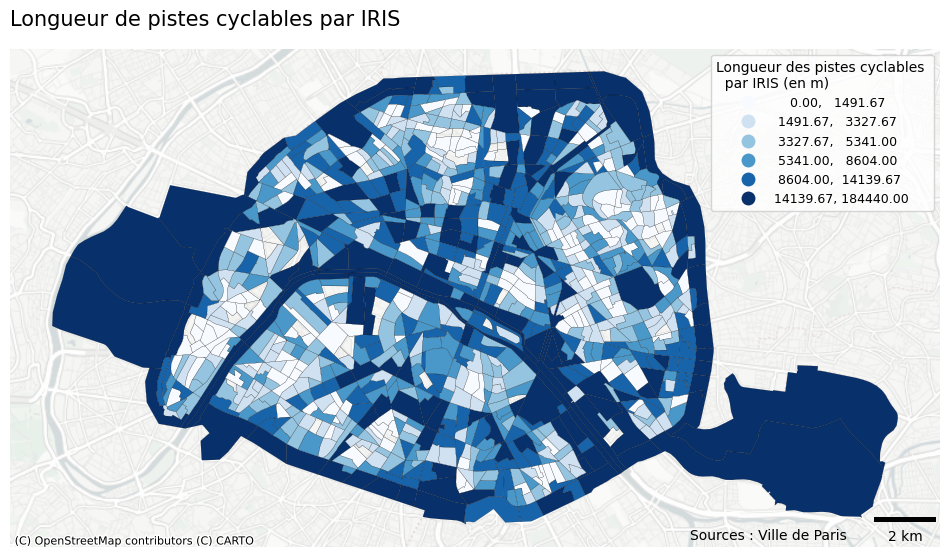

In [ ]:
#Cartographier la longeur des pistes cyclables par IRIS

Carte2, ax = plt.subplots(figsize=(12,12))

IRIS.boundary.to_crs('EPSG:3857').plot(ax=ax, linewidth=0.1, color = 'black')
IRISfinal.to_crs('EPSG:3857').plot(ax=ax, column="longueur", alpha=1, k=6, cmap='Blues',scheme='quantiles', categorical=False, legend=True,
                                   legend_kwds={'title': "Longueur des pistes cyclables \n  par IRIS (en m)", 'loc': 'upper right', 'title_fontsize':10, 'fontsize':9})

ctx.add_basemap(ax,  source=ctx.providers.CartoDB.PositronNoLabels)

ax.axis("off")
plt.title('Longueur de pistes cyclables par IRIS', loc='left', fontsize=15)
ax.text(0.90, 0.01, 'Sources : Ville de Paris', verticalalignment='bottom', horizontalalignment='right',
        transform=ax.transAxes, color='black', fontsize=10)
ax.add_artist(ScaleBar(1, length_fraction=0.1, location = "lower right", box_alpha=0, color="black"))

plt.show()

### Cartographie catégorisée

In [ ]:
# Faire une carte catégorisée en 3 modalités selon la longueur de pistes cyclables par IRIS (faible, moyen et elevée)


## Exporter des couches dans différents formats 💾


In [ ]:
# Exporter des couches

## En shapefile

IRISFINAL.to_file("IRISbis.shp")

## En GEOJSON

IRISFINAL.to_file("IRISbis.geojson", driver='GeoJSON')

## En Geopackage (pour combiner plusieurs couches)

IRISFINAL.to_file("Paris.gpkg", layer='countries', driver="GPKG")
Velibok.to_file("Paris.gpkg", layer='cities', driver="GPKG")

# Exercices autour des arbres de Paris 🌳

* Ne garder que les arbres de Paris
* Compter le nombre d'arbres par IRIS (jointure spatiale puis agrégations statistique)
* Verifier les sommes
* Calculer la hauteur moyenne des arbres par IRIS
* Faire la jointure attibutaire vers la couches des IRIS
* Faire une carte du nombre d'arbres par IRIS
* Faire une carte avec les hauteurs moyennes des arbres par IRIS

--2026-03-05 17:35:45--  https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/les-arbres/exports/parquet?lang=fr
Resolving opendata.paris.fr (opendata.paris.fr)... 18.200.140.238, 52.211.64.165
Connecting to opendata.paris.fr (opendata.paris.fr)|18.200.140.238|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/parquet]
Saving to: ‘arbres.parquet’

arbres.parquet          [     <=>            ]   9.26M  8.26MB/s    in 1.1s    

2026-03-05 17:35:47 (8.26 MB/s) - ‘arbres.parquet’ saved [9709656]



,idbase,typeemplacement,domanialite,arrondissement,complementadresse,adresse,idemplacement,libellefrancais,genre,espece,varieteoucultivar,circonferenceencm,hauteurenm,stadedeveloppement,remarquable,geo_point_2d
0,289193,Arbre,Alignement,PARIS 12E ARRDT,None,RUE JOSEPH KESSEL,000101028,Platane,Platanus,x hispanica,None,235,20,Adulte,NON,POINT (654829.514 6859612.078)
1,2007767,Arbre,Alignement,PARIS 1ER ARRDT,14 quai,PORT DU LOUVRE,000501011,Marronnier,Aesculus,sp.,None,100,8,Jeune (arbre)Adulte,NON,POINT (650946.037 6862456.326)
2,2025945,Arbre,Jardin,PARIS 1ER ARRDT,Les Lisières - Jardin d''Eau,JARDIN NELSON MANDELA / 32 RUE BERGER,B00106005,None,Prunus,None,None,55,5,Jeune (arbre)Adulte,NON,POINT (652011.703 6862707.313)


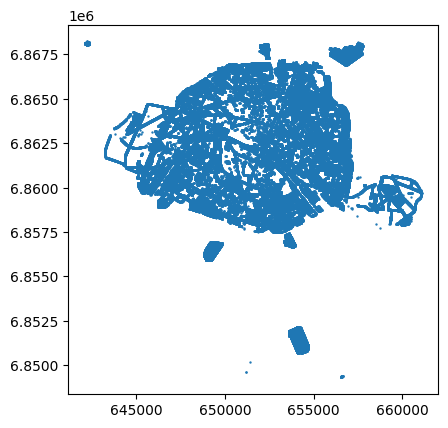

In [ ]:
# URL du fichier Parquet
!wget -O arbres.parquet https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/les-arbres/exports/parquet?lang=fr&timezone=Europe%2FBerlin

# Lire le parquet
arbres = gpd.read_parquet("arbres.parquet")

# Définir la colonne de géométrie active
arbres = arbres.set_geometry("geo_point_2d")

# Reprojection 2154
arbres = arbres.to_crs(2154)  # Lambert-93 pour la France

arbres.plot(markersize=0.5)
arbres.head(3)


In [ ]:
#Combien d'arbres dans la couche
len(arbres)

216869

In [ ]:
print(arbres.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 216869 entries, 0 to 216868
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   idbase              216869 non-null  int64   
 1   typeemplacement     216869 non-null  object  
 2   domanialite         216868 non-null  object  
 3   arrondissement      216869 non-null  object  
 4   complementadresse   73958 non-null   object  
 5   adresse             216869 non-null  object  
 6   idemplacement       216869 non-null  object  
 7   libellefrancais     214426 non-null  object  
 8   genre               216867 non-null  object  
 9   espece              212118 non-null  object  
 10  varieteoucultivar   38923 non-null   object  
 11  circonferenceencm   216869 non-null  int64   
 12  hauteurenm          216869 non-null  int64   
 13  stadedeveloppement  174376 non-null  object  
 14  remarquable         201055 non-null  object  
 15  geo_point

## Préparation des données

In [ ]:
#Réorganiser la table

arbres = arbres[["idbase", "domanialite", "arrondissement", "libellefrancais", "hauteurenm", "geo_point_2d"]]
arbres = arbres.rename(columns={"idbase": "idarbre", "domanialite": "domanialité", "arrondissement": "arrondissement", "libellefrancais": "type", "hauteurenm": "hauteur"}, errors="raise")
arbres.head()

,idarbre,domanialité,arrondissement,type,hauteur,geo_point_2d
0,289193,Alignement,PARIS 12E ARRDT,Platane,20,POINT (654829.514 6859612.078)
1,2007767,Alignement,PARIS 1ER ARRDT,Marronnier,8,POINT (650946.037 6862456.326)
2,2025945,Jardin,PARIS 1ER ARRDT,None,5,POINT (652011.703 6862707.313)
3,2016850,CIMETIERE,VAL-DE-MARNE,Arbre à soie,5,POINT (653621.586 6851717.031)
4,243930,Alignement,PARIS 16E ARRDT,Marronnier,5,POINT (644621.74 6861144.914)


In [ ]:
#Créer des index spatiaux sur les couches pour optimiser les traitements

arbres.sindex
arbres.has_sindex

IRIS.sindex
IRIS.has_sindex

True

<Axes: >

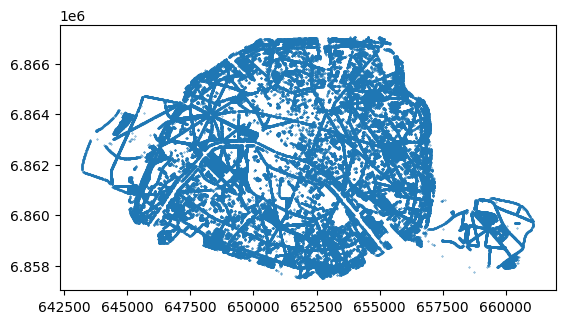

In [ ]:
#Ne garder que les arbres de la ville de Paris (environ 60 secondes sans index spatial)

arbres = gpd.overlay(arbres, IRIS, how='intersection')
arbres.plot(markersize=0.1)

### Faire des graphiques exploratoires

* Histogramme des hauteurs
* Répartition par arrondissement
* Répartition par IRIS
* Répartition par domanialité
* Répartition par type

<Axes: xlabel='arrondissement'>

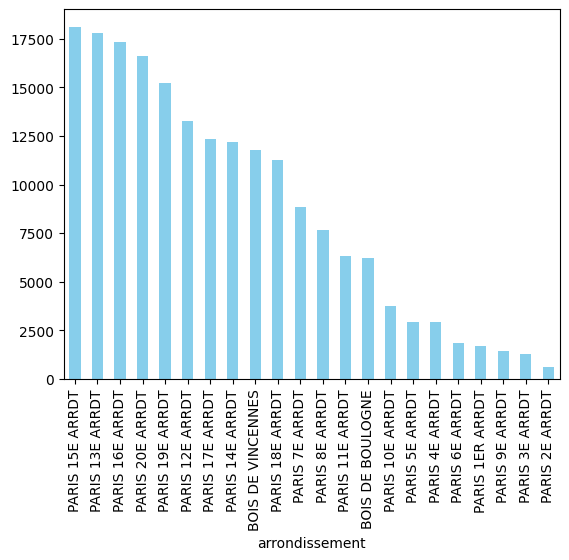

In [ ]:
# Exemple pour un graphique du nombre d'arbres par arrondissement

arbres_par_arrondissement = arbres['arrondissement'].value_counts()
arbres_par_arrondissement.head(5)
arbres_par_arrondissement.plot(kind='bar', color='skyblue')

## Analyse spatiale

In [ ]:
# Jointure spatiale Arbres <> IRIS
Arbres_IRIS = gpd.sjoin(arbres, IRIS)
Arbres_IRIS.head(3)

,idarbre,domanialité,arrondissement,type,hauteur,typ_iris_left,insee_com_left,code_iris_left,nom_iris_left,dep_left,...,typ_iris_right,insee_com_right,code_iris_right,nom_iris_right,dep_right,geo_point_2d_right,id_right,iris_right,nom_com_right,surface_right
0,289193,Alignement,PARIS 12E ARRDT,Platane,20,H,75112,751124701,Bercy 1,75,...,H,75112,751124701,Bercy 1,75,"[48.83500636958479, 2.3858739099242756]",IRIS____0000000751124701,4701,Paris 12e Arrondissement,0.058250
1,2007767,Alignement,PARIS 1ER ARRDT,Marronnier,8,D,75101,751010199,Seine et Berges,75,...,D,75101,751010199,Seine et Berges,75,"[48.85902984337017, 2.3361552057194395]",IRIS____0000000751010199,0199,Paris 1er Arrondissement,0.233484
2,2025945,Jardin,PARIS 1ER ARRDT,None,5,A,75101,751010205,Les Halles 5,75,...,A,75101,751010205,Les Halles 5,75,"[48.862297570166575, 2.34534858519305]",IRIS____0000000751010205,0205,Paris 1er Arrondissement,0.068570


In [ ]:
# Compter le nombre d'arbres par IRIS

NbArbres  = Arbres_IRIS[["code_iris_right", "idarbre"]].groupby("code_iris_right").size()
NbArbres =pd.DataFrame(NbArbres)
NbArbres = NbArbres.rename(columns={0: 'NbArbres'})
NbArbres.head(5)

,NbArbres
code_iris_right,
751010101,138
751010102,61
751010103,47
751010199,488
751010201,165


In [ ]:
#Verification somme

total1 = Arbres_IRIS['idarbre'].size
total2 = NbArbres['NbArbres'].sum()

print(f"Nombre total d'arbres dans la couche de départ : {total1}")
print(f"Nombre total d'arbres après agrégation  : {total2}")

Nombre total d'arbres dans la couche de départ : 191318
Nombre total d'arbres après agrégation  : 191318


In [ ]:
# Faire la jointure attributaire

IRISArbres = IRIS.merge(NbArbres, left_on='code_iris', right_on='code_iris_right')
IRISArbres.head(3)

,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry,surface,NbArbres
0,A,75112,751124811,Quinze-Vingts 11,75,"[48.844104305775815, 2.3753123018512237]",IRIS____0000000751124811,4811,Paris 12e Arrondissement,"POLYGON ((653849.2 6860793.5, 653962.2 6860809...",0.115311,2
1,D,75115,751156023,Jardin Citroën-Cévennes,75,"[48.840354178960965, 2.2752169001780462]",IRIS____0000000751156023,6023,Paris 15e Arrondissement,"POLYGON ((646761.8 6860630.1, 646782.5 6860618...",0.142982,1885
2,A,75108,751083006,Faubourg du Roule 6,75,"[48.874120601261225, 2.308949350470029]",IRIS____0000000751083006,3006,Paris 8e Arrondissement,"POLYGON ((649501.3 6863891.5, 649444.3 6863864...",0.040529,30


In [ ]:
# Calculer la hauteur moyenne des arbres par IRIS

Hauteurmoyenne = Arbres_IRIS[["code_iris_right", "hauteur"]].groupby("code_iris_right").mean()
Hauteurmoyenne.head()

,hauteur
code_iris_right,
751010101,8.710145
751010102,9.606557
751010103,6.851064
751010199,10.165984
751010201,6.981818


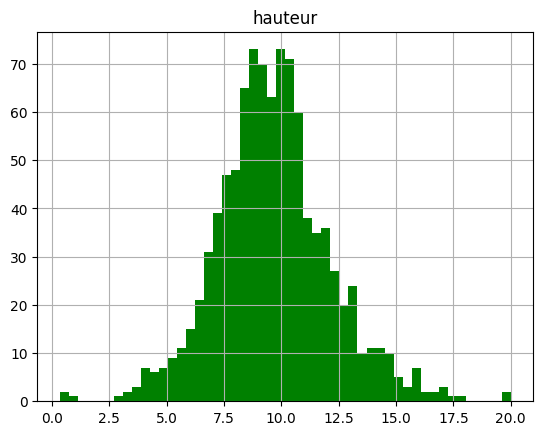

In [ ]:
hist = Hauteurmoyenne.hist(bins=50, color="green")

In [ ]:
# Faire la jointure attributaire

IRISfinal = IRISArbres.merge(Hauteurmoyenne, left_on='code_iris', right_on='code_iris_right')
IRISfinal.head()

,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry,surface,NbArbres,hauteur
0,A,75112,751124811,Quinze-Vingts 11,75,"[48.844104305775815, 2.3753123018512237]",IRIS____0000000751124811,4811,Paris 12e Arrondissement,"POLYGON ((653849.2 6860793.5, 653962.2 6860809...",0.115311,2,10.000000
1,D,75115,751156023,Jardin Citroën-Cévennes,75,"[48.840354178960965, 2.2752169001780462]",IRIS____0000000751156023,6023,Paris 15e Arrondissement,"POLYGON ((646761.8 6860630.1, 646782.5 6860618...",0.142982,1885,0.370292
2,A,75108,751083006,Faubourg du Roule 6,75,"[48.874120601261225, 2.308949350470029]",IRIS____0000000751083006,3006,Paris 8e Arrondissement,"POLYGON ((649501.3 6863891.5, 649444.3 6863864...",0.040529,30,10.266667
3,D,75107,751072812,Champ de Mars,75,"[48.85609158677385, 2.2979056002416494]",IRIS____0000000751072812,2812,Paris 7e Arrondissement,"POLYGON ((648026.7 6862221.3, 648266.6 6862471...",0.268362,1744,9.896216
4,H,75110,751103902,Porte Saint-Martin 2,75,"[48.87001277527335, 2.36487060942211]",IRIS____0000000751103902,3902,Paris 10e Arrondissement,"POLYGON ((653570.4 6863368, 653449.3 6863312, ...",0.059112,4,4.000000


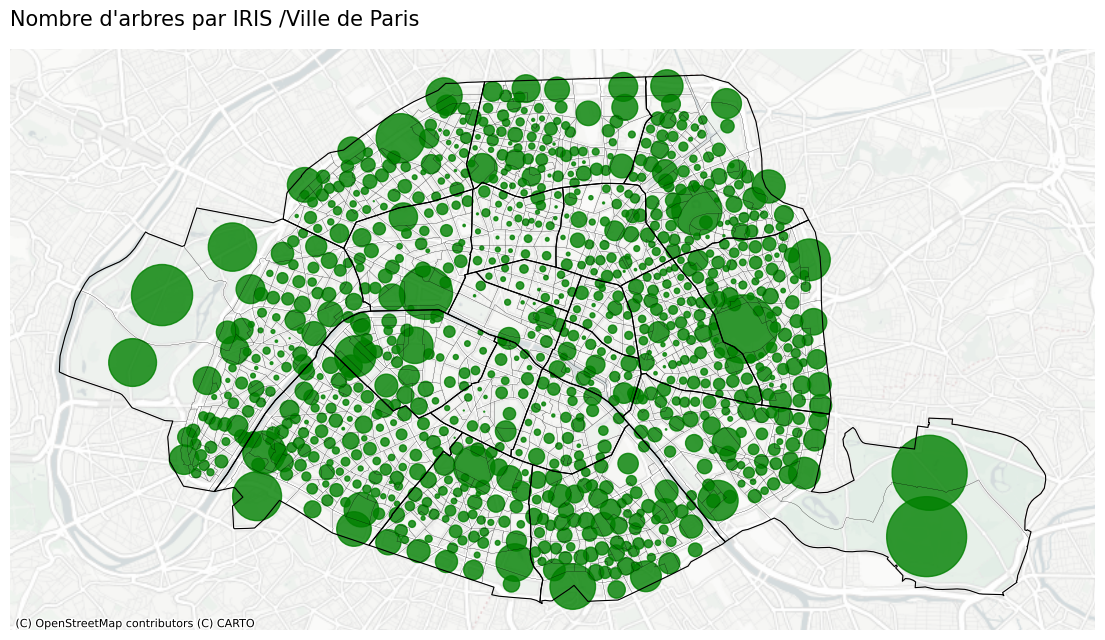

In [ ]:
#Cartographier le nombre d'arbres par IRIS > Ajouter une légende
IRISfinalcentro = IRISfinal.copy()
IRISfinalcentro.geometry = IRISfinalcentro['geometry'].centroid

sizes = IRISfinalcentro['NbArbres'] *0.5  # Ajustez le facteur multiplicatif selon vos besoins


map3, ax = plt.subplots(figsize=(14,14))

ARDT.boundary.to_crs('EPSG:3857').plot(ax=ax, linewidth=0.8, color = 'black')
IRIS.boundary.to_crs('EPSG:3857').plot(ax=ax, linewidth=0.1, color = 'black')
IRISfinalcentro.to_crs('EPSG:3857').plot(ax=ax, markersize=sizes, alpha=0.8, color='green', legend=True)
ctx.add_basemap(ax,  source=ctx.providers.CartoDB.PositronNoLabels)

plt.title("Nombre d'arbres par IRIS /Ville de Paris", loc='left', fontsize=15)
ax.axis("off")

plt.show()

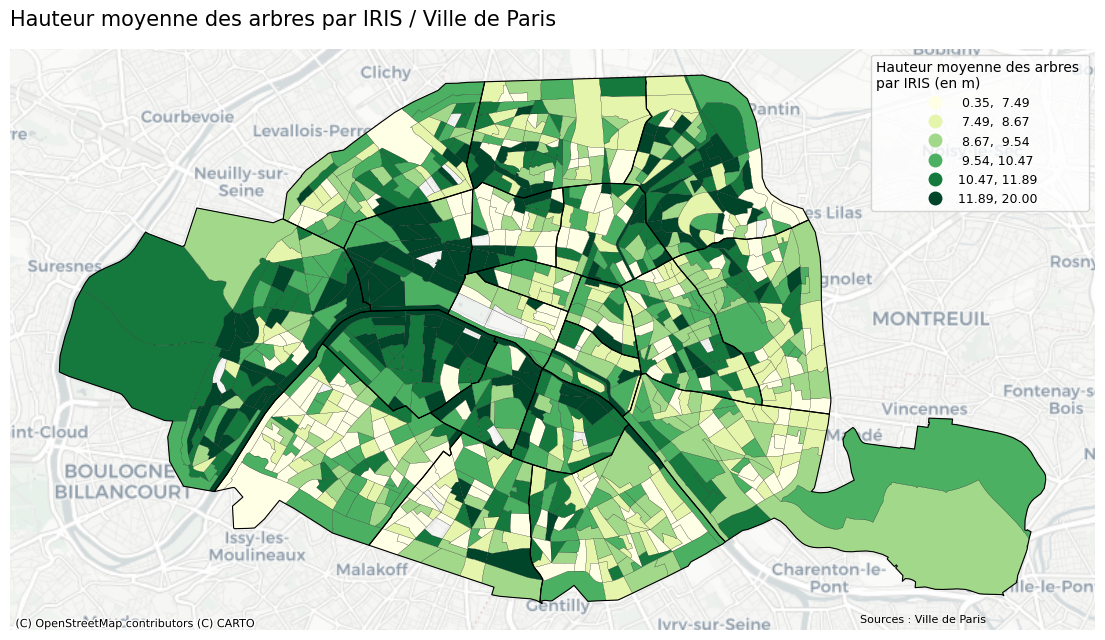

In [ ]:
#Cartographier la hauteur moyenne des arbres par IRIS

map3, ax = plt.subplots(figsize=(14,14))

ARDT.boundary.to_crs('EPSG:3857').plot(ax=ax, linewidth=0.8, color = 'black')
IRIS.boundary.to_crs('EPSG:3857').plot(ax=ax, linewidth=0.1, color = 'black')
IRISfinal.to_crs('EPSG:3857').plot(ax=ax, k=6, column="hauteur", alpha=1, cmap='YlGn',scheme='quantiles', categorical=False, legend=True,
                                    legend_kwds={'title': "Hauteur moyenne des arbres \npar IRIS (en m)", 'loc': 'upper right', 'title_fontsize':10, 'fontsize':9})
ctx.add_basemap(ax,  source=ctx.providers.CartoDB.Positron)

plt.title("Hauteur moyenne des arbres par IRIS / Ville de Paris", loc='left', fontsize=15)
ax.text(0.90, 0.01, 'Sources : Ville de Paris', verticalalignment='bottom', horizontalalignment='right', transform=ax.transAxes, color='black', fontsize=8)
ax.axis("off")

plt.show()

# Carroyage et agrégation spatiales 🟩

## Méthode 1 > Carroyage "manuel"

In [ ]:
# Création d'un carroyage de 300m x 300m (20 secondes)

from shapely.geometry import box

def create_grid(ArbresParis, grid_size=300): # Tailles des cellulles
    # Obtenir l'emprise
    minx, miny, maxx, maxy = arbres.total_bounds

    # Liste pour stocker les cellules de la grille
    grid_cells = []
    IDgrid = 1

    # Boucles pour générer la grille
    x = minx
    while x < maxx:
        y = miny
        while y < maxy:
            cell = box(x, y, x + grid_size, y + grid_size)
            grid_cells.append({"IDgrid": IDgrid, "geometry": cell})
            IDgrid += 1
            y += grid_size
        x += grid_size

    # Créer un GeoDataFrame avec le même CRS que ArbresParis
    grid_gdf = gpd.GeoDataFrame(grid_cells, crs=arbres.crs)

    # Filtrer pour ne garder que les cellules qui intersectent avec la couche des arbres
    grid_gdf = grid_gdf[grid_gdf.intersects(arbres.unary_union)]

    return grid_gdf

# Utilisation avec un GeoDataFrame existant
Grille = create_grid(arbres)


/tmp/ipykernel_522/398175471.py:28: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  grid_gdf = grid_gdf[grid_gdf.intersects(arbres.unary_union)]


KeyboardInterrupt: 

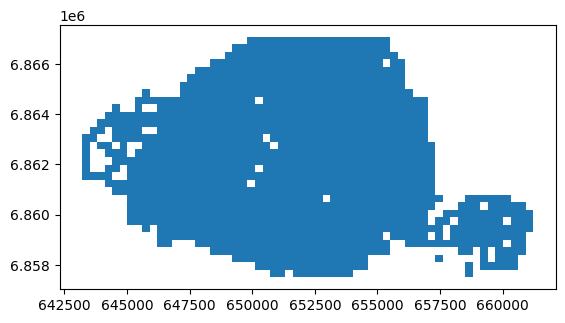

In [ ]:
# Création d'un index spatial sur le carroyage + check de la couche
Grille.sindex
Grille.plot()
Grille.head(3)

In [ ]:
#Jointure spatiale Arbres <> Carroyage

Arbrescell = gpd.sjoin(arbres, Grille[["IDgrid", "geometry"]])
Arbrescell.head(2)

,idarbre,domanialité,arrondissement,type,hauteur,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,surface,geometry,index_right,IDgrid
0,289193,Alignement,PARIS 12E ARRDT,Platane,20,H,75112,751124701,Bercy 1,75,"[48.83500636958479, 2.3858739099242756]",IRIS____0000000751124701,4701,Paris 12e Arrondissement,0.058250,POINT (654829.514 6859612.078),1223,1224
1,2007767,Alignement,PARIS 1ER ARRDT,Marronnier,8,D,75101,751010199,Seine et Berges,75,"[48.85902984337017, 2.3361552057194395]",IRIS____0000000751010199,0199,Paris 1er Arrondissement,0.233484,POINT (650946.037 6862456.326),816,817


In [ ]:
# Compter le nombre d'arbres par maille

NbarbresMailles  = Arbrescell[["IDgrid", "idarbre"]].groupby("IDgrid").size()
NbarbresMailles =pd.DataFrame(NbarbresMailles)
NbarbresMailles = NbarbresMailles.rename(columns={0: 'Nbarbres'})
NbarbresMailles.head(5)

,Nbarbres
IDgrid,
14,32
15,24
16,29
17,26
18,31


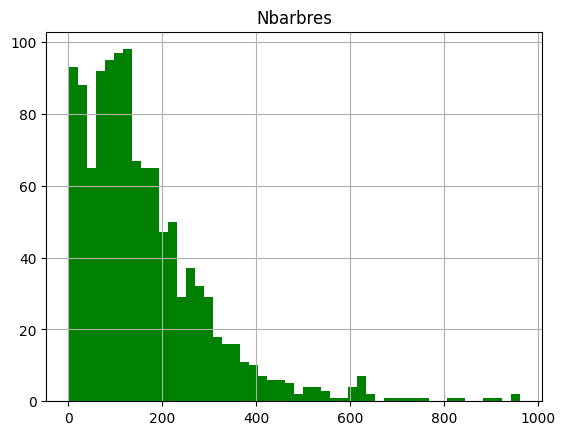

In [ ]:
hist = NbarbresMailles.hist(bins=50, color="green")

In [ ]:
# Faire la jointure attributaire

MaillageArbres = Grille.merge(NbarbresMailles, left_on='IDgrid', right_on='IDgrid')
MaillageArbres.head()

,IDgrid,geometry,Nbarbres
0,14,"POLYGON ((643511.094 6861397.042, 643511.094 6...",32
1,15,"POLYGON ((643511.094 6861697.042, 643511.094 6...",24
2,16,"POLYGON ((643511.094 6861997.042, 643511.094 6...",29
3,17,"POLYGON ((643511.094 6862297.042, 643511.094 6...",26
4,18,"POLYGON ((643511.094 6862597.042, 643511.094 6...",31


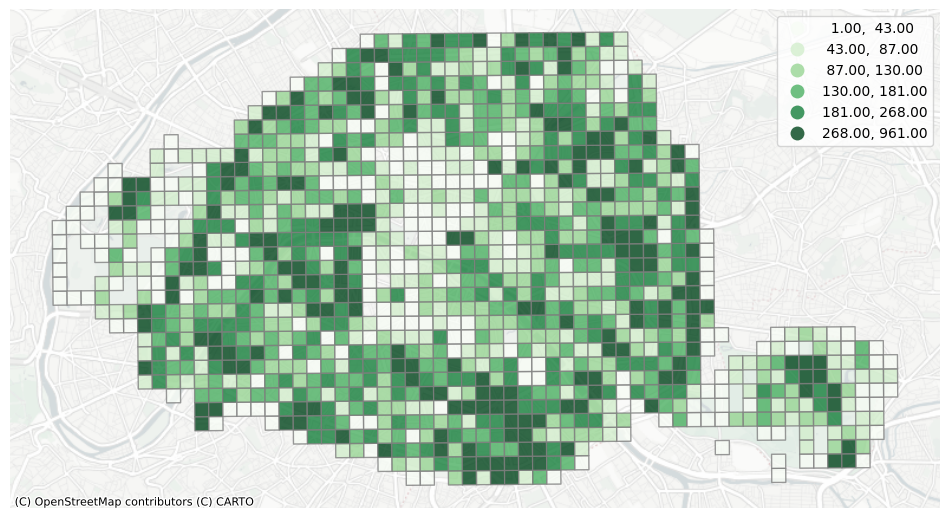

In [ ]:
# Cartographier avec une belle mise en page

CarroyageArbres, ax = plt.subplots(figsize=(12,12))

MaillageArbres.to_crs('EPSG:3857').plot(ax=ax, column='Nbarbres', figsize=(12, 12), k=6, cmap='Greens', scheme='quantiles', edgecolor="grey", alpha=0.8, legend = 'true')
ax.axis("off")
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)

plt.show()

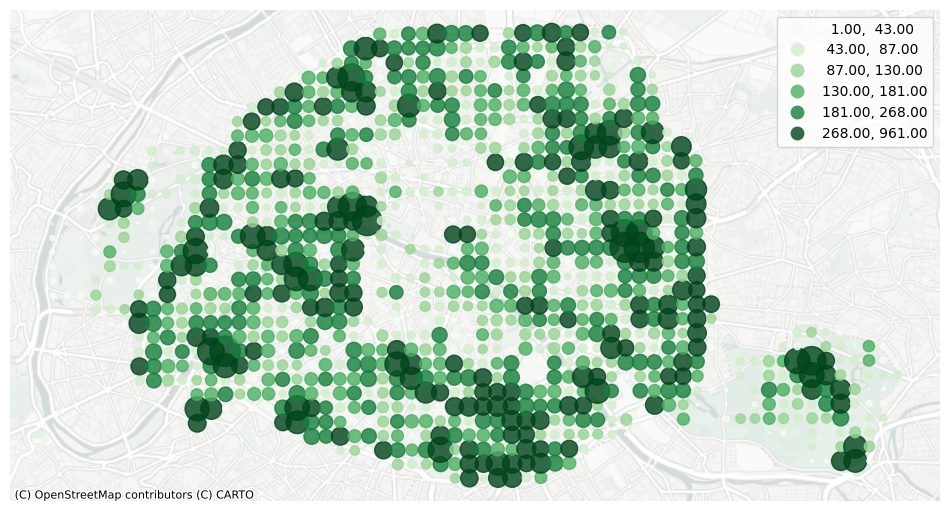

In [ ]:
MaillageArbres.geometry = MaillageArbres['geometry'].centroid

CarroyageArbres, ax = plt.subplots(figsize=(12,12))

MaillageArbres.to_crs('EPSG:3857').plot(ax=ax, column="Nbarbres", figsize=(12, 12), k=6, cmap='Greens', scheme='quantiles',
                                        markersize = MaillageArbres["Nbarbres"]/2, alpha=0.8, legend = 'true')
ax.axis("off")
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)

plt.show()

## Méthode 2 > H3 Uber Index

* https://h3geo.org/
* https://h3geo.org/docs/core-library/restable


In [ ]:
# Installer H3
!pip install h3

# Importer H3
import h3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.2 MB/s eta 0:00:00


In [ ]:
# Avant d'aller plus loin avec cette méthode il faut REPROJETER le jeu de données en entrée

arbresH3 = arbres.to_crs(4326)

In [ ]:
#Création du maillage

h3_level = 9 #ici un maillage hexagonale de niveau 9 (vous pouvez changer la résolution)

def lat_lng_to_h3(row):
    return h3.latlng_to_cell(row.geometry.x, row.geometry.y, h3_level)

arbresH3['h3'] = arbresH3.apply(lat_lng_to_h3, axis=1)

In [ ]:
# Vérifier le nombre de mailles
arbresH3["h3"].nunique()

1651

In [ ]:
#Dénombrement des arbres par maille

counts = arbresH3.groupby(['h3']).h3.agg('count').to_frame('count').reset_index()
counts.head(5)

,h3,count
0,897aa50661bffff,12
1,897aa506647ffff,37
2,897aa50664fffff,403
3,897aa50665bffff,37
4,897aa50667bffff,4


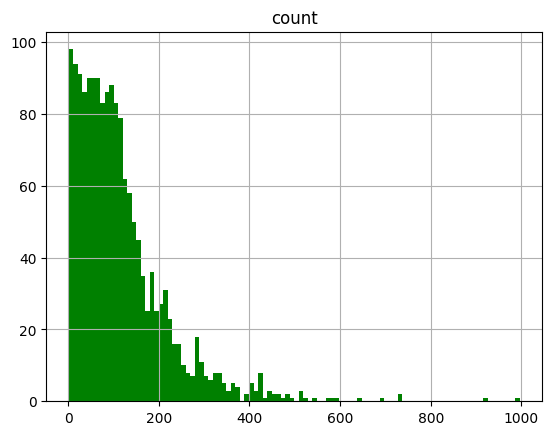

In [ ]:
#Histogramme de distribution de l'agrégation spatiale

hist = counts.hist(bins=100, color ='green')

,h3,count,geometry
0,897aa50661bffff,12,"POLYGON ((2.44513 48.82175, 2.44686 48.82169, ..."
1,897aa506647ffff,37,"POLYGON ((2.45033 48.82159, 2.45206 48.82154, ..."
2,897aa50664fffff,403,"POLYGON ((2.45282 48.82298, 2.45455 48.82293, ..."
3,897aa50665bffff,37,"POLYGON ((2.44993 48.82748, 2.45166 48.82743, ..."
4,897aa50667bffff,4,"POLYGON ((2.45302 48.82004, 2.45475 48.81999, ..."


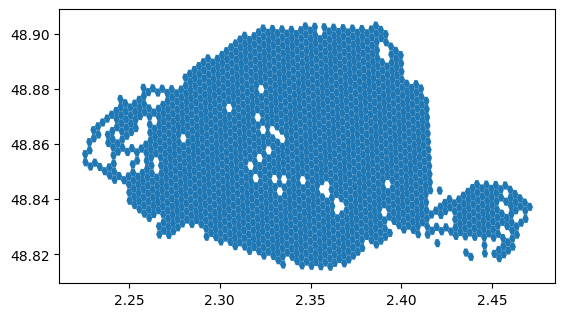

In [ ]:
# Création de la géométrie du maillage (Version 4)

def add_geometry(row):
    points = h3.cell_to_boundary(row['h3'])
    return Polygon(points)

counts['geometry'] = counts.apply(add_geometry, axis=1)
Mailage = gpd.GeoDataFrame(counts, crs='EPSG:4326')
Mailage.plot()
Mailage.head()

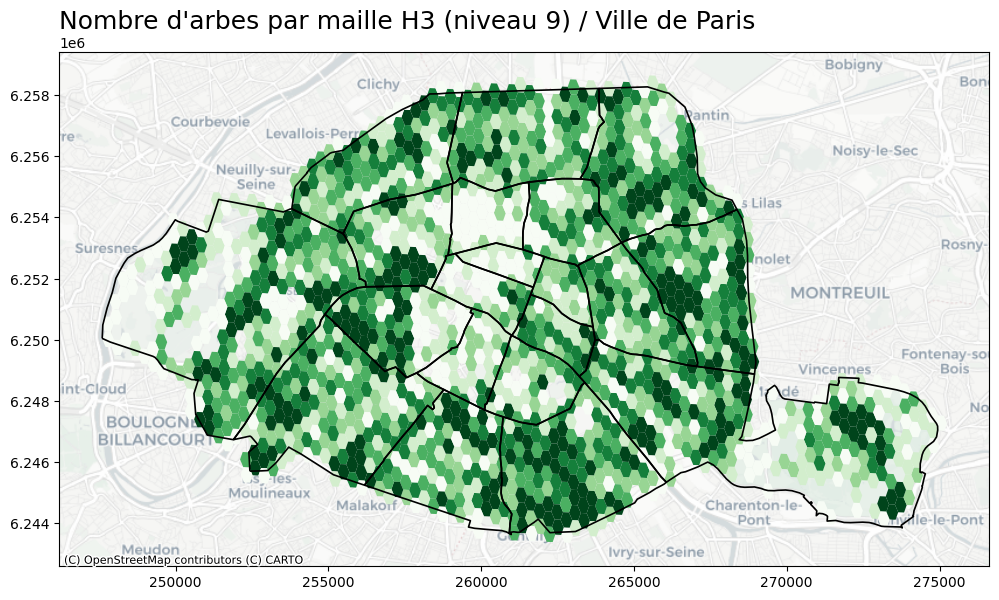

In [ ]:
# Cartographie

H3Map, ax = plt.subplots(figsize=(12,12))

Mailage.to_crs('EPSG:3857').plot(ax=ax, column='count',k=6, cmap='Greens', scheme='quantiles')
ARDT.boundary.to_crs('EPSG:3857').plot(ax=ax, linewidth=1.2, color = 'black')

ctx.add_basemap(ax,  source=ctx.providers.CartoDB.Positron)

plt.title("Nombre d'arbes par maille H3 (niveau 9) / Ville de Paris", loc='left', fontsize=18)

plt.show()

#### Faire une carte avec les hauteurs moyennes dans un maillage de niveau 10

In [ ]:
#Exemple d'une syntaxe de calcul d'une moyenne
mean  = arbresgeo[["h3", "hauteur"]].groupby(["h3"])['hauteur'].mean().reset_index(name='mean')
mean.head(5)

# Overture Maps 💠

* Pour rappel du projet : https://overturemaps.org/
* Pour explorer les données : https://explore.overturemaps.org/#15/38.90678/-77.03649
* Pour télécharger les données : https://spatialhub.online/

--2025-04-02 11:16:22--  https://data.rennesmetropole.fr/api/explore/v2.1/catalog/datasets/quartiers-prioritaires/exports/geojson?lang=fr
Resolving data.rennesmetropole.fr (data.rennesmetropole.fr)... 18.200.140.238, 52.211.64.165
Connecting to data.rennesmetropole.fr (data.rennesmetropole.fr)|18.200.140.238|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/json]
Saving to: ‘QPV.geojson’

QPV.geojson             [ <=>                ]  40.93K  --.-KB/s    in 0s      

2025-04-02 11:16:23 (177 MB/s) - ‘QPV.geojson’ saved [41909]



<Axes: >

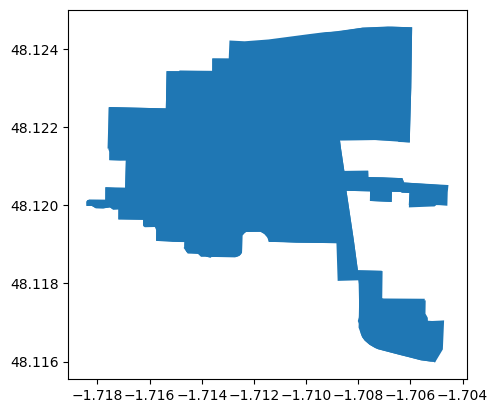

In [ ]:
#Téléchargement des contours des QPV de Rennes
!wget -O QPV.geojson https://data.rennesmetropole.fr/api/explore/v2.1/catalog/datasets/quartiers-prioritaires/exports/geojson?lang=fr&timezone=Europe%2FBerlin

#Importer et reprojeter la couche des QPV
QPV= gpd.read_file("QPV.geojson", encoding='utf-8')
QPV = QPV[(QPV["nom_qp"] == 'Villejean')]
QPV.plot()

In [ ]:
# Définir la bounding box pour le téléchargement

QPVbbox= QPV.total_bounds
print(QPVbbox)

[-1.71841775 48.11597691 -1.70453897 48.12457597]


In [ ]:
# Installer la librairie Python de Overture Maps

! pip install overturemaps
import overturemaps

In [ ]:
# Afficher l'aide

! overturemaps download --help

Usage: overturemaps download [OPTIONS]

Options:
  --bbox BBOX
  -f [geojson|geojsonseq|geoparquet]
                                  [required]
  -o, --output PATH
  -t, --type [address|bathymetry|building|building_part|division|division_area|division_boundary|place|segment|connector|infrastructure|land|land_cover|land_use|water]
                                  [required]
  --help                          Show this message and exit.


,id,geometry,theme,type,version,sources,level,subtype,class,height,...,min_height,min_floor,facade_color,facade_material,roof_material,roof_shape,roof_direction,roof_orientation,roof_color,roof_height
0,08b1863199308fff0200ae71f1e5548b,"POLYGON ((-1.71829 48.11684, -1.71836 48.11684...",buildings,building,0,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,None,None,NaN,...,NaN,NaN,None,None,None,None,NaN,None,None,NaN
1,08b1863199309fff02005b7b8f9ce2b1,"POLYGON ((-1.7182 48.11671, -1.71816 48.11657,...",buildings,building,0,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,commercial,office,NaN,...,NaN,NaN,None,None,None,flat,NaN,None,None,NaN
2,08b1863199372fff0200e334241ef051,"POLYGON ((-1.71815 48.11644, -1.71813 48.11637...",buildings,building,0,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,commercial,office,NaN,...,NaN,NaN,None,None,None,None,NaN,None,None,NaN
3,08b186319930dfff02004fbdc514b6d2,"POLYGON ((-1.7178 48.11701, -1.71767 48.11701,...",buildings,building,0,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,commercial,None,NaN,...,NaN,NaN,None,None,None,None,NaN,None,None,NaN
4,08b1863199361fff0200d175c47a327c,"POLYGON ((-1.71568 48.11596, -1.71567 48.1156,...",buildings,building,0,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,None,None,NaN,...,NaN,NaN,None,None,None,None,NaN,None,None,NaN


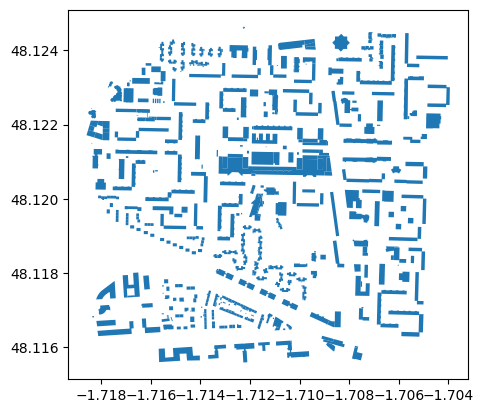

In [ ]:
# Télécharger les données des bâtiments d'une zone
! overturemaps download --bbox=-1.71841775,48.11597691,-1.70453897,48.12457597 \
    -f geoparquet --type=building --output=Rennes.geoparquet

# Charger et afficher le jeu de données
OvertureBuildings = gpd.read_parquet("Rennes.geoparquet")
OvertureBuildings.plot()
OvertureBuildings.head()